In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import scipy.sparse as scipy_sparse

from qlinks.caging import (
    CageSolverConfig,
    CandidateFilterContext,
    CombinedBoundaryKineticTargetNullityFilter,
    run_candidate_filters,
    solve_candidate,
    type1_candidates_from_bipartite_self_loops,
    type2_candidates_from_self_loops,
)
from qlinks.models import (
    SquareQLMModel,
    SquareQDMModel,
    TriangularQLMModel,
    TriangularQDMModel,
    HoneycombQLMModel,
    HoneycombQDMModel,
)
from qlinks.visualizer import (
    BasisConfigurationVisualizer,
    LinkVisualStyle,
    HamiltonianGraphStyle,
    HamiltonianGraphVisualizer,
)
from qlinks.visualizer import BasisGridVisualizer

In [2]:
def diagonal_values(matrix) -> np.ndarray:
    """Return diagonal values of a dense or sparse matrix."""
    if scipy_sparse.issparse(matrix):
        values = matrix.diagonal()
    else:
        values = np.diag(matrix)

    return np.asarray(values, dtype=np.complex128)


def offdiagonal_nnz(matrix) -> int:
    """Return number of off-diagonal nonzero entries."""
    sparse_matrix = scipy_sparse.csr_array(matrix).copy()
    sparse_matrix.setdiag(0)
    sparse_matrix.eliminate_zeros()

    return int(sparse_matrix.nnz)


def bipartition_labels(adjacency_matrix) -> np.ndarray:
    """Return bipartition labels for an undirected sparse graph."""
    sparse_matrix = scipy_sparse.csr_array(adjacency_matrix).copy()
    sparse_matrix.setdiag(0)
    sparse_matrix.eliminate_zeros()
    sparse_matrix.data = np.ones_like(sparse_matrix.data, dtype=np.int8)
    sparse_matrix = sparse_matrix.maximum(sparse_matrix.T).tocsr()

    n_vertices = sparse_matrix.shape[0]
    labels = -np.ones(n_vertices, dtype=np.int64)

    for start_index in range(n_vertices):
        if labels[start_index] != -1:
            continue

        labels[start_index] = 0
        queue = [start_index]

        while queue:
            vertex_index = queue.pop(0)
            neighbors = sparse_matrix.indices[
                sparse_matrix.indptr[vertex_index] : sparse_matrix.indptr[vertex_index + 1]
            ]

            for neighbor_index in neighbors:
                neighbor_index = int(neighbor_index)

                if labels[neighbor_index] == -1:
                    labels[neighbor_index] = 1 - labels[vertex_index]
                    queue.append(neighbor_index)
                elif labels[neighbor_index] == labels[vertex_index]:
                    raise ValueError("Graph is not bipartite.")

    return labels


def normalized_full_state(
    local_state: np.ndarray,
    support: np.ndarray,
    hilbert_size: int,
) -> np.ndarray:
    """Embed a compact local cage state into the full Hilbert space."""
    full_state = np.zeros(hilbert_size, dtype=np.complex128)
    full_state[support] = local_state

    norm = np.linalg.norm(full_state)

    if norm == 0:
        raise ValueError("Cannot normalize a zero state.")

    return full_state / norm


def signature_from_energy_and_self_loop(
    energy_value: complex,
    self_loop_value: complex,
    *,
    tolerance: float,
) -> tuple[int, int] | None:
    """Infer integer signature ``(kappa, Z)``."""
    potential_value = int(round(self_loop_value.real))
    kinetic_value = energy_value.real - self_loop_value.real
    kinetic_integer = int(round(kinetic_value))

    if not np.isclose(
        self_loop_value.real,
        potential_value,
        atol=tolerance,
        rtol=0.0,
    ):
        return None

    if not np.isclose(
        kinetic_value,
        kinetic_integer,
        atol=tolerance,
        rtol=0.0,
    ):
        return None

    return kinetic_integer, potential_value


def append_independent_state(
    independent_states: list[np.ndarray],
    candidate_state: np.ndarray,
    *,
    tolerance: float,
) -> None:
    """Append the state only if it increases the span."""
    normalized_candidate = candidate_state / np.linalg.norm(candidate_state)

    if len(independent_states) == 0:
        independent_states.append(normalized_candidate)
        return

    existing_matrix = np.column_stack(independent_states)
    old_rank = np.linalg.matrix_rank(existing_matrix, tol=tolerance)

    extended_matrix = np.column_stack(
        [
            existing_matrix,
            normalized_candidate,
        ]
    )
    new_rank = np.linalg.matrix_rank(extended_matrix, tol=tolerance)

    if new_rank > old_rank:
        independent_states.append(normalized_candidate)

In [3]:
model = TriangularQDMModel(
    lx=4,
    ly=4,
    boundary_condition="periodic",
    # winding_a=0,
    # winding_b=0,
    kinetic=1.0,
    potential=1.0,
)

build_result = model.build(
    basis_solver="dfs",
    builder="sparse",
    backend="scipy",
    sort_basis=True,
    on_missing="raise",
)

hamiltonian_matrix = build_result.hamiltonian
kinetic_matrix = build_result.kinetic
potential_matrix = build_result.potential
basis = build_result.basis

print("n_states =", basis.n_states)
print("H shape =", hamiltonian_matrix.shape)
print("H nnz =", hamiltonian_matrix.nnz)
print("K nnz =", kinetic_matrix.nnz)
print("K offdiag nnz =", offdiagonal_nnz(kinetic_matrix))
print("V nnz =", potential_matrix.nnz)
print("K is bipartite =", nx.is_bipartite(nx.from_scipy_sparse_array(kinetic_matrix, edge_attribute="weight")))

n_states = 1920
H shape = (1920, 1920)
H nnz = 10740
K nnz = 8832
K offdiag nnz = 8832
V nnz = 1908
K is bipartite = True


In [17]:
tolerance = 1e-10

self_loop_values = diagonal_values(potential_matrix)
labels = bipartition_labels(kinetic_matrix)

type1_candidate_subgraphs = type1_candidates_from_bipartite_self_loops(
    kinetic_matrix,
    self_loop_values,
    labels,
    min_component_size=2,
)

type2_candidate_subgraphs = type2_candidates_from_self_loops(
    kinetic_matrix,
    self_loop_values,
    min_component_size=2,
)

print("type1 candidates =", len(type1_candidate_subgraphs))
print("type2 candidates =", len(type2_candidate_subgraphs))

print(
    "type1 candidate signatures =",
    Counter(
        candidate.metadata.get("signature")
        for candidate in type1_candidate_subgraphs
    ),
)

print(
    "type2 candidate signatures =",
    Counter(
        candidate.metadata.get("signature")
        for candidate in type2_candidate_subgraphs
    ),
)

type1 candidates = 115
type2 candidates = 252
type1 candidate signatures = Counter({(0, 5.0): 27, (1, 4.0): 24, (0, 3.0): 24, (0, 4.0): 12, (1, 3.0): 12, (0, 6.0): 12, (1, 6.0): 4})
type2 candidate signatures = Counter({(4.0,): 96, (3.0,): 96, (6.0,): 60})


In [18]:
candidate_subgraphs = type1_candidate_subgraphs
allowed_kappas = (0,)

solver_config = CageSolverConfig(
    tolerance=tolerance,
    validate_full_residual=True,
)

filter_context = CandidateFilterContext(
    kinetic_matrix=kinetic_matrix,
    self_loop_values=self_loop_values,
)

candidate_filters = [
    CombinedBoundaryKineticTargetNullityFilter(
        target_kappas=tuple(float(kappa_value) for kappa_value in allowed_kappas),
        tolerance=tolerance,
        require_nonzero_kappa=False,
    ),
]

hilbert_size = hamiltonian_matrix.shape[0]

cage_states_by_signature: dict[tuple[int, int], list[np.ndarray]] = {}
compact_cage_records = []

for candidate_subgraph in candidate_subgraphs:
    filter_result = run_candidate_filters(
        filter_context,
        candidate_subgraph,
        candidate_filters,
    )

    if not filter_result.accepted:
        continue

    cage_states = solve_candidate(
        hamiltonian_matrix,
        candidate_subgraph,
        config=solver_config,
    )

    for cage_state in cage_states:
        self_loop_value = self_loop_values[candidate_subgraph.vertices[0]]
        signature = signature_from_energy_and_self_loop(
            cage_state.energy,
            self_loop_value,
            tolerance=10 * tolerance,
        )

        if signature is None:
            continue

        kinetic_value, potential_value = signature

        if kinetic_value not in allowed_kappas:
            continue

        full_state = normalized_full_state(
            cage_state.local_state,
            cage_state.support,
            hilbert_size,
        )

        states_for_signature = cage_states_by_signature.setdefault(
            signature,
            [],
        )

        old_count = len(states_for_signature)

        append_independent_state(
            states_for_signature,
            full_state,
            tolerance=100 * tolerance,
        )

        if len(states_for_signature) > old_count:
            compact_cage_records.append(
                {
                    "signature": signature,
                    "candidate": candidate_subgraph,
                    "cage_state": cage_state,
                    "full_state": full_state,
                    "support": cage_state.support,
                }
            )

observed_counts_by_signature = {
    signature: len(states)
    for signature, states in cage_states_by_signature.items()
}

print("observed counts =", observed_counts_by_signature)
print("number of stored compact cage records =", len(compact_cage_records))

observed counts = {(0, 6): 21, (0, 4): 12}
number of stored compact cage records = 33


In [19]:
target_signature = (0, 4)

matching_records = [
    record
    for record in compact_cage_records
    if record["signature"] == target_signature
]

if not matching_records:
    raise RuntimeError(f"No cage state found with signature {target_signature}.")

record = matching_records[0]

cage_state = record["cage_state"]
full_state = record["full_state"]
support = record["support"]

print("signature =", record["signature"])
print("energy =", cage_state.energy)
print("support =", support.tolist())
print("support size =", support.size)
print("boundary residual =", cage_state.boundary_residual)
print("eigen residual =", cage_state.eigen_residual)
print("full residual =", cage_state.full_residual)
print("state weight on support =", full_state[support])

signature = (0, 4)
energy = (3.999999999999999+0j)
support = [13, 68, 310, 355, 1318, 1348, 1504, 1534]
support size = 8
boundary residual = 4.8672866219197025e-15
eigen residual = 6.280369834735101e-16
full residual = 4.907637875040192e-15
state weight on support = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]


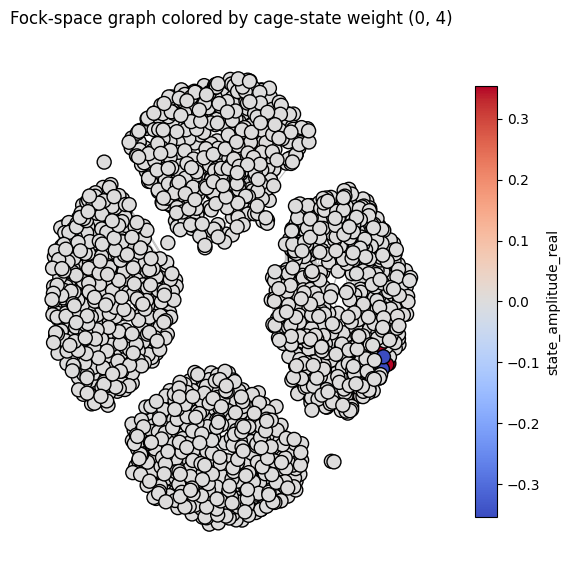

<Axes: title={'center': 'Fock-space graph colored by cage-state weight (0, 4)'}>

In [20]:
graph_visualizer = HamiltonianGraphVisualizer.from_sparse_matrix(
    kinetic_matrix,
    include_self_loops=False,
    style=HamiltonianGraphStyle(cmap="coolwarm"),
)

graph_visualizer.plot(
    backend="igraph",
    color_by="state_amplitude_real",
    state_vector=full_state,
    layout="kk",
    title=f"Fock-space graph colored by cage-state weight {target_signature}",
)

In [8]:
def finite_amplitude_indices(
    state_vector: np.ndarray,
    *,
    tolerance: float = 1e-12,
) -> np.ndarray:
    """Return basis indices with numerically nonzero amplitude."""
    return np.flatnonzero(np.abs(state_vector) > tolerance).astype(np.int64)


def basis_states_array(basis):
    """Extract the raw basis-state array."""
    if hasattr(basis, "states"):
        return np.asarray(basis.states)

    if hasattr(basis, "configs"):
        return np.asarray(basis.configs)

    raise AttributeError(
        "Expected basis to expose either `states` or `configs`."
    )

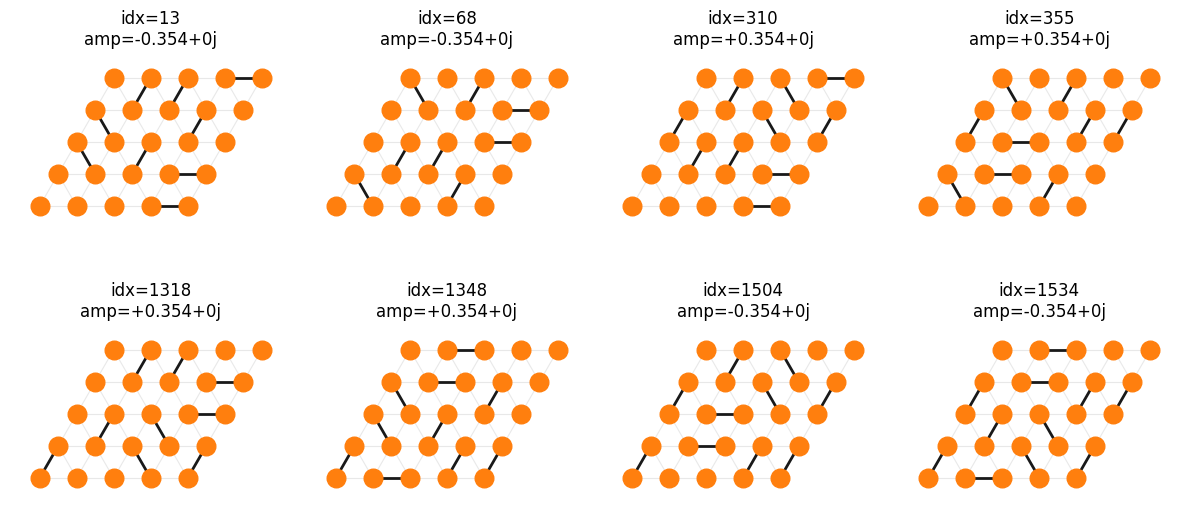

finite-amplitude basis indices = [13, 68, 310, 355, 1318, 1348, 1504, 1534]
number of plotted basis states = 8


In [21]:
amplitude_tolerance = 1e-10

nonzero_indices = finite_amplitude_indices(
    full_state,
    tolerance=amplitude_tolerance,
)

basis_state_array = basis_states_array(basis)
support_states = basis_state_array[nonzero_indices]

labels = [
    f"idx={int(basis_index)}\n"
    f"amp={full_state[int(basis_index)].real:+.3g}"
    f"{full_state[int(basis_index)].imag:+.3g}j"
    for basis_index in nonzero_indices
]

grid_visualizer = BasisGridVisualizer(
    lattice=model.lattice,
    layout=model.layout,
    periodic_image_mode="positive_patch",
    collapse_duplicate_visual_links=True,
    site_label_style="sublattice_cell",
    # coordinate_transform=np.array(
    #     [
    #         [1.0, 0.0],
    #         [0.0, 0.72],
    #     ],
    #     dtype=float,
    # ),
    # style=LinkVisualStyle(
    #     node_size=50.0,
    #     # plaquette_symbol_offset=(-0.01, 0.01),
    # ),
)

grid_visualizer.plot(
    support_states,
    labels=labels,
    mode="dimers",
    plaquette_symbols="none",
    ncols=4,
    show_config_label=False,
    # suptitle="Basis states with finite cage-state amplitude",
    single_plot_kwargs={
        "with_site_labels": False,
        "with_site_values": False,
        "with_link_values": False,
    },
)

print("finite-amplitude basis indices =", nonzero_indices.tolist())
print("number of plotted basis states =", len(nonzero_indices))

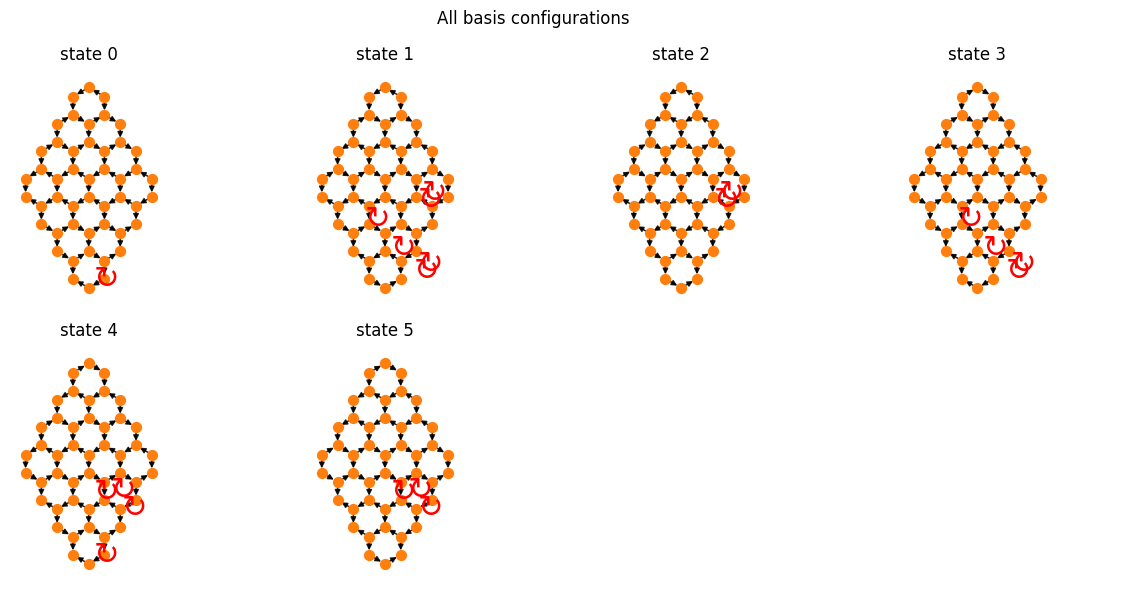

(<Figure size 1200x600 with 8 Axes>,
 array([[<Axes: title={'center': 'state 0'}>,
         <Axes: title={'center': 'state 1'}>,
         <Axes: title={'center': 'state 2'}>,
         <Axes: title={'center': 'state 3'}>],
        [<Axes: title={'center': 'state 4'}>,
         <Axes: title={'center': 'state 5'}>, <Axes: >, <Axes: >]],
       dtype=object))

In [12]:
grid_visualizer = BasisGridVisualizer(
    lattice=model.lattice,
    layout=model.layout,
    periodic_image_mode="positive_patch",
    collapse_duplicate_visual_links=True,
    site_label_style="sublattice_cell",
    coordinate_transform=np.array(
        [
            [1.0, 0.0],
            [0.0, 0.72],
        ],
        dtype=float,
    ),
    style=LinkVisualStyle(
        node_size=50.0,
        # plaquette_symbol_offset=(-0.01, 0.01),
    ),
)

grid_visualizer.plot(
    basis.states,
    ncols=4,
    mode="arrows",
    plaquette_symbols="circulation",
    show_config_label=False,
    suptitle="All basis configurations",
    single_plot_kwargs={
        "with_site_labels": False,
        "with_site_values": False,
        "with_link_values": False,
    },
)